# Exemple d'utilisation de gridmarthe [FR]

Ce tutoriel est repris de la documentation de gridmarthe et adapté pour la formation.
Documentation complète : https://gridmarthe.readthedocs.io/en/latest/

/!\ Cette partie n'est PAS accessible sur jupyterlite, il faut télécharger le notebook
et l'executer en local.

Le package gridmarthe est conçu pour faciliter la lecture/l'écriture de grille au format Marthe.
Ce notebook permet d'explorer quelques fonctionnalités de base du package et de montrer un exemple
de traitement des grilles.

In [1]:
# import du package
import gridmarthe as gm

## Fonctionnalités de base

Les grilles contiennent certaines métadonnées, dont l'index du pas de temps
mais pas les dates en elles-même. Aussi, il est utile de fournir à la fonction de lecture
soit une série de date (à construire manuellement) soit un fichier pastp pour que les dates soient
lues automatiquement.

En complément, plusieurs arguments peuvent être utiles à la lecture (retrait des valeurs nulles, transformation des xy, ajout de l'indicateur de maillage ou des numéros de colonnes/lignes, etc.).

Pour évaluer les options possibles, on peut afficher l'aide de la fonction.

In [2]:
help(gm.load_marthe_grid)

Help on function load_marthe_grid in module gridmarthe.gridmarthe:

load_marthe_grid(filename, varname=None, dates=None, fpastp=None, nanval=None, dropna=False, xyfactor=1, keepligcol=False, add_id_grid=False, title=None, var_attrs={}, model_attrs={'resolution_units': 'm', 'projection': 'epsg:27572', 'domain': 'FR-France'}, verbose=True)
    LECSEM python wrapper
    Fortran modules from marthe src wrapped for python module
    
    memo :  file.out read as seq => all layer then nested grid and all layers too. And so on for every timestep.
            coords with no value read as 1e+20
            zvar read as a single 1D array for every timestep
    
    Parameters
    ----------
        filename    (str):  A path to marthegrid file (*.permh, *.out, etc.)
        varname     (str):  variable to access in martgrid file, e.g `CHARGE` for groundwater head. See marthegrid file content.
                            if None  is passed (default), function will scan all varnames in filename an

In [ ]:
# lecture d'une grille marthe et stockage dans un Dataset (librairie xarray)
ds = gm.load_marthe_grid(
    './data/chasim_hallue.out', 'CHARGE',
    fpastp='./data/hallue.pastp',
    drop_nan=True # si la valeur des nans n'est pas 9999 (ex. permh, NaNs = 0), on peut spécifier la valeur
)

In [4]:
# affichage des valeurs et attributs
ds

<xarray.Dataset> Size: 784kB
Dimensions:  (time: 205, zone: 927)
Coordinates:
  * time     (time) datetime64[ns] 2kB 1995-07-31 1995-08-01 ... 2012-07-01
  * zone     (zone) int64 7kB 255 256 257 258 259 ... 2722 2723 2724 2725 2726
Data variables:
    charge   (time, zone) float32 760kB 100.0 100.6 101.1 ... 27.0 26.0 26.35
    x        (zone) float32 4kB 617.8 618.2 618.8 619.2 ... 606.8 607.2 607.8
    y        (zone) float32 4kB 2.567e+03 2.567e+03 ... 2.543e+03 2.543e+03
    dx       (zone) float32 4kB 0.5 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5
    dy       (zone) float32 4kB 0.5 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5
Attributes: (12/16)
    conventions:          CF-1.10
    title:                Modélisation du bassin de la SOMME Nappe_Libre
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 53 54 1
    lon_resolution:       0.5
    lat_resolution:       0.5
    ...                   ...
    creation_date:        Created on 2024-06-18T20:44:48Z UTC
    institution:          BRGM, French Geological Survey, Orléans, France
    comment:              Hydrogeological model created with MARTHE code (Thi...
    resolution_units:     m
    projection:           epsg:27572
    domain:               FR-France

La grille est chargée dans un objet xarray 2D, de dimension (time, zone).
La dimension spatiale est donc 1D, contenue dans zone. Chaque zone possède un couple de coordonnées xy, stocké en variable (et non en dimension).
Ce format permet d'effecture de nombreuses opérations de manière plus efficaces qu'en 2 ou 3D + time.
Il suffit d'assigner les coordonnées (transformation en 2 ou 3D + temps) avant les fonctionnalités graphiques.

In [ ]:
# on ajoute les coordonées
ds_3d = gm.assign_coords(ds)
# a noter que les fonctions sont aussi accessibles par méthodes/attributs:
ds_3d

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 48, x: 44, time: 205)
Coordinates:
  * y        (y) float32 192B 2.543e+03 2.544e+03 ... 2.566e+03 2.567e+03
  * x        (x) float32 176B 599.2 599.8 600.2 600.8 ... 619.8 620.2 620.8
  * time     (time) datetime64[ns] 2kB 1995-07-31 1995-08-01 ... 2012-07-01
Data variables:
    charge   (time, y, x) float32 2MB nan nan nan nan ... 102.7 103.4 103.5
    dx       (y, x) float32 8kB nan nan nan nan nan nan ... 0.5 0.5 0.5 0.5 0.5
    dy       (y, x) float32 8kB nan nan nan nan nan nan ... 0.5 0.5 0.5 0.5 0.5
Attributes: (12/16)
    conventions:          CF-1.10
    title:                Modélisation du bassin de la SOMME Nappe_Libre
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 53 54 1
    lon_resolution:       0.5
    lat_resolution:       0.5
    ...                   ...
    creation_date:        Created on 2024-06-18T20:44:48Z UTC
    institution:          BRGM, French Geological Survey, Orléans, France
    comment:              Hydrogeological model created with MARTHE code (Thi...
    resolution_units:     m
    projection:           epsg:27572
    domain:               FR-France

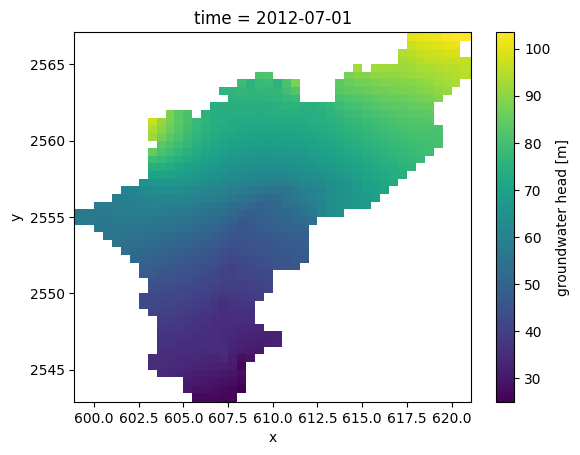

In [6]:
# on plot à un instant t
ds_3d.isel(time=-1)['charge'].plot.pcolormesh(x='x',y='y')

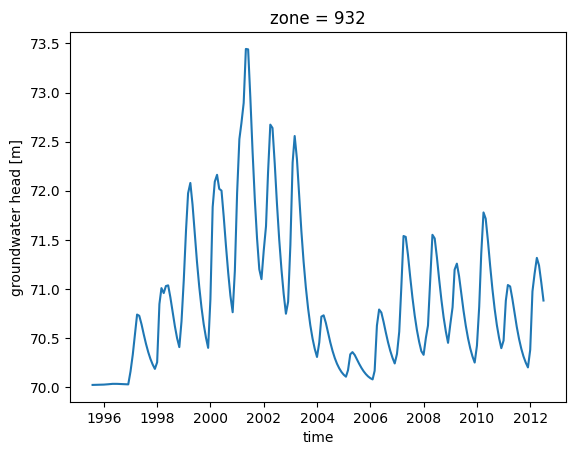

In [7]:
# ou la chronique dans une maille
ds.isel(zone=255)['charge'].plot()

Pour les gigognes, une fonction de plot spécifique est proposée (`gm.plot_nested_grids()`).

Pour les modèles avec plusieurs couches, on peut récupérer les couches de surfaces~: `gm.get_min_layer(ds, [subset_layers=[3,5]])`

ou même afficher ce résultat~: `gm.plot_outcrop()`


Les fonctions natives de xarray, numpy permettent d'ores-et-déjà d'accéder à certaines fonctionnalités de Operasem (substitution de valeurs, transformation, opérations entre deux grilles, etc.)

## Exemple de traitements

In [ ]:
# compute diff between grids

In [ ]:
# compute seasonal mean